True Time: 1234
Estimated Time: 1993
Reconstruction Error: 759


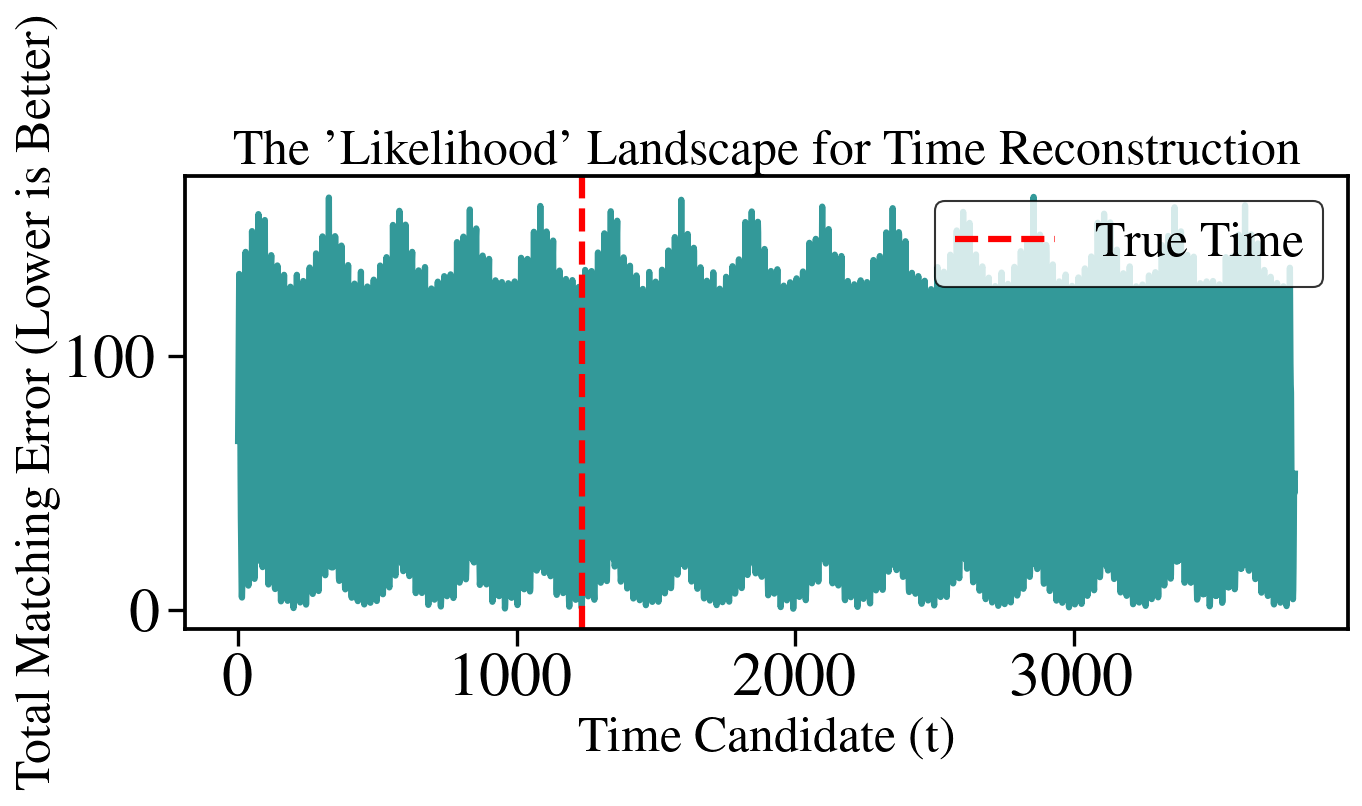

In [61]:
import numpy as np
import matplotlib.pyplot as plt

def reconstruct_time_robust(measured_phases, frequencies, max_range):
    """
    Finds the time 't' that best fits all measured phases simultaneously.
    This is much more stable than the standard CRT formula.
    """
    # Create a range of possible 'candidate' times
    t_candidates = np.arange(0, max_range, 1)
    
    # Calculate the 'residual' error for every possible time
    # We want to find t where (t % freq) is closest to measured_phase
    total_error = np.zeros_like(t_candidates, dtype=float)
    
    for phi, freq in zip(measured_phases, frequencies):
        # Expected remainder for this candidate time
        expected = t_candidates % freq
        # Circular distance (since phase 0.1 is close to 0.9 on a clock)
        diff = np.abs(expected - phi)
        # Handle the wrap-around (e.g., if freq=10, 0 and 9 are 1 unit apart)
        diff = np.minimum(diff, freq - diff)
        total_error += diff**2
        
    # The best estimate is the time that minimizes the total error
    best_t = t_candidates[np.argmin(total_error)]
    return best_t, total_error

# 1. Define your Frequencies (The "m" values from CRT)
# Let's use your Prime-Binary set:
periods = [3, 5, 11, 23] 
max_period = np.lcm.reduce(periods)  # BUG FIX #2: was np.prod — use lcm for dynamic range

# 2. Simulate a "True Time" we want to measure
t_true = 1234

# 3. Simulate Quantum Measurement (with 5% noise)
noise_scale = 0.2
# BUG FIX #1: was "frequencies" (undefined) — should be "periods"
measured_phases = [(t_true % f) + np.random.normal(0, noise_scale) for f in periods]

# 4. Reconstruct using our Search Method
t_est, error_curve = reconstruct_time_robust(measured_phases, periods, max_period)

print(f"True Time: {t_true}")
print(f"Estimated Time: {t_est}")
print(f"Reconstruction Error: {abs(t_true - t_est)}")

# --- Visualization of the Search Space ---
plt.figure(figsize=(10, 4))
plt.plot(error_curve, color='teal', alpha=0.8)
plt.axvline(t_true, color='red', linestyle='--', label='True Time')
plt.title("The 'Likelihood' Landscape for Time Reconstruction")
plt.xlabel("Time Candidate (t)")
plt.ylabel("Total Matching Error (Lower is Better)")
plt.legend()
plt.show()

In [10]:
# 1. Define your Frequencies (The "m" values from CRT)
# Let's use your Prime-Binary set:
periods = [3, 5, 7, 11, 17] 
max_period = np.lcm.reduce(periods) # This is our Dynamic Range (19635)
print(max_period)

# 2. Simulate a "True Time" we want to measure
t_true = 10415

# 3. Simulate Quantum Measurement 
noise_scale = 0.1
measured_phases = [(t_true % f) + np.random.normal(0, noise_scale) for f in periods]

# 4. Reconstruct using our Search Method
t_est, error_curve = reconstruct_time_robust(measured_phases, periods, max_period)

print(f"True Time: {t_true}")
print(f"Estimated Time: {t_est}")
print(f"Reconstruction Error: {abs(t_true - t_est)}")

19635
True Time: 10415
Estimated Time: 10415
Reconstruction Error: 0


In [62]:
# 1. Define your Frequencies (The "m" values from CRT)
# Seth's Hitchhiker's set of periods:
periods = [42, 43, 47] 
max_period = np.lcm.reduce(periods)

# 2. Simulate a "True Time" we want to measure
t_true = 23897

# 3. Simulate Quantum Measurement 
noise_scale = 5
# BUG FIX #1: was "frequencies" (undefined) — should be "periods"
measured_phases = [(t_true % f) + np.random.normal(0, noise_scale) for f in periods]

# 4. Reconstruct using our Search Method
t_est, error_curve = reconstruct_time_robust(measured_phases, periods, max_period)

print(f"True Time: {t_true}")
print(f"Estimated Time: {t_est}")
print(f"Reconstruction Error: {abs(t_true - t_est)}")

True Time: 23897
Estimated Time: 67377
Reconstruction Error: 43480


In [63]:
print(np.lcm.reduce(periods))

84882


In [64]:
import numpy as np

def reconstruct_robust_crt_xia(k_tilde, lambdas, M, Gamma, sigma=1.0):
    """
    Implementation of the Robust Phase Unwrapping algorithm
    from Xia & Wang (Equations 6-11).
    """
    L = len(lambdas)
    # Step 1: Calculate coprime factors Gamma_i (Eq 4)
    Gammas = [int(round(Gamma * l)) for l in lambdas]
    
    # Step 2: Calculate gamma_i values (Eq 5)
    # gamma_1 = product of all Gamma_j for j != 1
    gamma_1 = np.prod(Gammas[1:])
    
    # Precompute gamma_i for each i (product of all Gamma_j for j != i)
    # Needed to constrain ni_hat search range per Eq 6
    gamma_all = []
    for idx in range(L):
        g = 1
        for j in range(L):
            if j != idx:
                g *= Gammas[j]
        gamma_all.append(g)
    
    # Step 3: Find S_i sets (Eq 6 & 7)
    # For each pair (channel 1, channel i), find n1 candidates that minimize
    # |n_bar_i * M_i + r_tilde_i - n_bar_1 * M_1 - r_tilde_1|
    S_i_1 = [] 
    
    for i in range(1, L): 
        best_diff = float('inf')
        S_i_current = []
        gamma_i = gamma_all[i]  # valid range for n_bar_i
        
        # Search range for n1_hat: [0, gamma_1 - 1] per Eq 6
        for n1_hat in range(gamma_1):
            val_1 = n1_hat * Gammas[0] + (k_tilde[0] * Gammas[0]) / M
            
            # BUG FIX #3: Compute ni_hat by rounding, then CLAMP to valid range [0, gamma_i - 1]
            # Per Eq 6, n_bar_i must be in [0, gamma_i - 1].
            # Without this, out-of-range ni_hat values produce artificially small residuals
            # that can pollute the candidate sets.
            ni_hat_raw = (val_1 - (k_tilde[i] * Gammas[i]) / M) / Gammas[i]
            ni_hat = int(round(ni_hat_raw))
            ni_hat = max(0, min(gamma_i - 1, ni_hat))  # Clamp to valid range
            
            # Calculate the residual for this candidate pair (Eq 6)
            current_diff = abs(ni_hat * Gammas[i] + (k_tilde[i] * Gammas[i]) / M - 
                               n1_hat * Gammas[0] - (k_tilde[0] * Gammas[0]) / M)
            
            if current_diff < best_diff - 1e-9: # Found a new better minimum
                best_diff = current_diff
                S_i_current = [n1_hat]
            elif abs(current_diff - best_diff) < 1e-9: # Tied with current minimum
                S_i_current.append(n1_hat)
        
        S_i_1.append(set(S_i_current))

    # Step 4: Intersection of all candidate sets (Eq 8)
    S = S_i_1[0].intersection(*S_i_1[1:])
    
    if len(S) != 1:
        return None, f"Failure: Found {len(S)} possible solutions. Theorem 1 bounds likely violated."
    
    n1 = list(S)[0]
    
    # Step 5: Solve for all folding integers ni based on the unique n1
    n_all = [n1]
    for i in range(1, L):
        val_1 = n1 * Gammas[0] + (k_tilde[0] * Gammas[0]) / M
        ni = int(round((val_1 - (k_tilde[i] * Gammas[i]) / M) / Gammas[i]))
        n_all.append(ni)
        
    # Step 6: Final estimate of x using the averaging formula (Eq 11)
    estimate_x = (1 / (sigma * L)) * sum((n_all[i] + k_tilde[i] / M) * lambdas[i] for i in range(L))
    
    return estimate_x, n_all


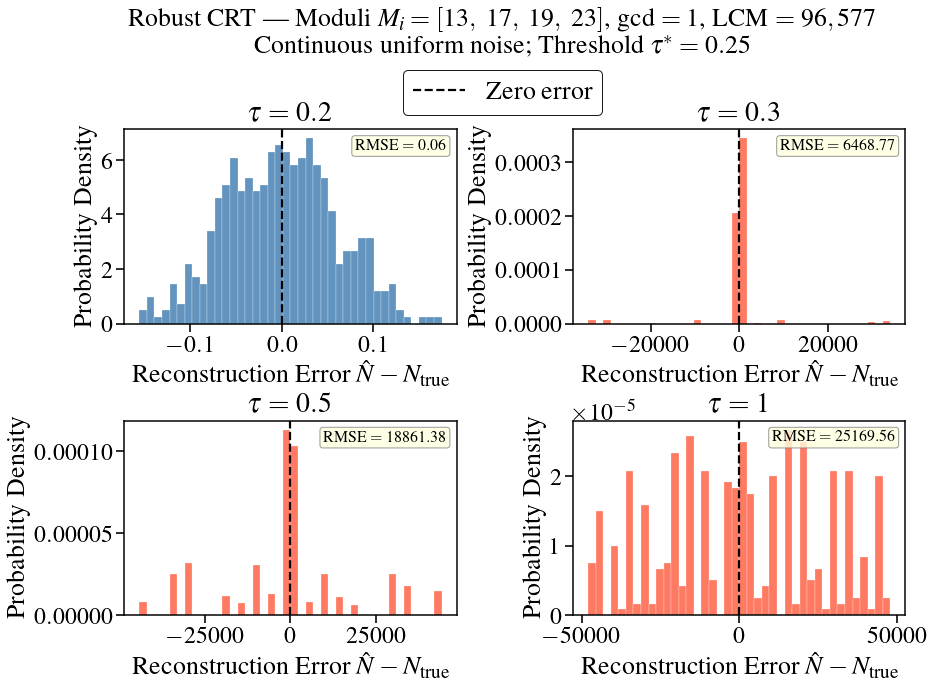

In [16]:
from math import gcd, prod, lcm
from functools import reduce
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams.update({
    'text.usetex'         : True,
    'text.latex.preamble' : r'\usepackage{mathptmx} \usepackage{amssymb}',
    'font.family'         : 'serif',
    'font.size'           : 26,
    'axes.titlesize'      : 28,
    'axes.labelsize'      : 26,
    'xtick.labelsize'     : 24,
    'ytick.labelsize'     : 24,
    'legend.fontsize'     : 22,
    'axes.linewidth'      : 1.5,
})

def robust_crt_int(r_tilde, moduli):
    """Accepts float r_tilde and non-integer inputs — returns float estimate."""
    L = len(moduli)
    M_g = reduce(gcd, moduli)
    Gammas = [m // M_g for m in moduli]
    gamma = [prod(Gammas[j] for j in range(L) if j != i) for i in range(L)]
    S_sets = []
    for i in range(1, L):
        best_diff, candidates = float('inf'), []
        for n1_hat in range(gamma[0]):
            ni_hat = round((n1_hat * moduli[0] + r_tilde[0] - r_tilde[i]) / moduli[i])
            ni_hat = max(0, min(gamma[i] - 1, ni_hat))
            diff = abs(ni_hat * moduli[i] + r_tilde[i]
                       - n1_hat * moduli[0] - r_tilde[0])
            if diff < best_diff - 1e-9:
                best_diff, candidates = diff, [n1_hat]
            elif abs(diff - best_diff) < 1e-9:
                candidates.append(n1_hat)
        S_sets.append(set(candidates))
    S = S_sets[0].intersection(*S_sets[1:])
    if len(S) != 1:
        return None
    n1 = list(S)[0]
    n_all = [n1] + [round((n1 * moduli[0] + r_tilde[0] - r_tilde[i]) / moduli[i])
                    for i in range(1, L)]
    return sum(n_all[i] * moduli[i] + r_tilde[i] for i in range(L)) / L

moduli    = [13, 17, 19, 23]
M_gcd     = reduce(gcd, moduli)
M_lcm     = reduce(lcm, moduli)
threshold = M_gcd / 4

N_trials   = 500
tau_values = [0.2, 0.3, 0.5, 1]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
plt.subplots_adjust(hspace=0.5, wspace=0.35, top=0.80)
rng = np.random.default_rng(42)

legend_handle = None

for idx, tau in enumerate(tau_values):
    errors   = []
    n_failed = 0

    for _ in range(N_trials):
        N_true  = rng.uniform(0, M_lcm)
        rems    = [N_true % m for m in moduli]
        noise   = rng.uniform(-tau, tau, size=len(moduli)).tolist()
        noisy_r = [r + n for r, n in zip(rems, noise)]
        result  = robust_crt_int(noisy_r, moduli)
        if result is not None:
            err = (result - N_true + M_lcm / 2) % M_lcm - M_lcm / 2
            errors.append(err)
        else:
            n_failed += 1

    ax    = axes.flatten()[idx]
    valid = (tau < threshold)
    color = 'steelblue' if valid else 'tomato'

    if errors:
        errors_arr = np.array(errors, dtype=float)
        rmse       = np.sqrt(np.mean(errors_arr ** 2))
        ax.hist(errors_arr, bins=40, color=color, edgecolor='white',
                linewidth=0.3, alpha=0.85, density=True)
        line = ax.axvline(0, color='black', linestyle='--', linewidth=2.2,
                          label='Zero error')
        if legend_handle is None:
            legend_handle = line
        stats_text = rf'RMSE $= {rmse:.2f}$'
        ax.text(0.97, 0.95, stats_text, transform=ax.transAxes,
                ha='right', va='top', fontsize=16,
                bbox=dict(boxstyle='round,pad=0.2', facecolor='lightyellow',
                          edgecolor='gray', alpha=0.8))

    ax.set_title(rf'$\tau = {tau}$', pad=8)
    ax.set_xlabel(r'Reconstruction Error $\hat{N} - N_{\mathrm{true}}$')
    ax.set_ylabel('Probability Density')

moduli_str = '[' + ',\\ '.join(str(m) for m in moduli) + ']'
fig.suptitle(
    rf'Robust CRT --- Moduli $M_i = {moduli_str}$,  gcd~$= {M_gcd}$,  LCM~$= {M_lcm:,}$'
    + '\n' +
    rf'Continuous uniform noise; Threshold~$\tau^* = {threshold:.2f}$',
    fontsize=26, fontweight='bold', y=0.97
)
fig.legend(handles=[legend_handle], loc='upper center',
           bbox_to_anchor=(0.5, 0.9), ncol=1, framealpha=0.9, fontsize=26)

fig.savefig('CRT_robust_simulation.svg', bbox_inches='tight')
fig.savefig('CRT_robust_simulation.pdf', bbox_inches='tight')
plt.show()


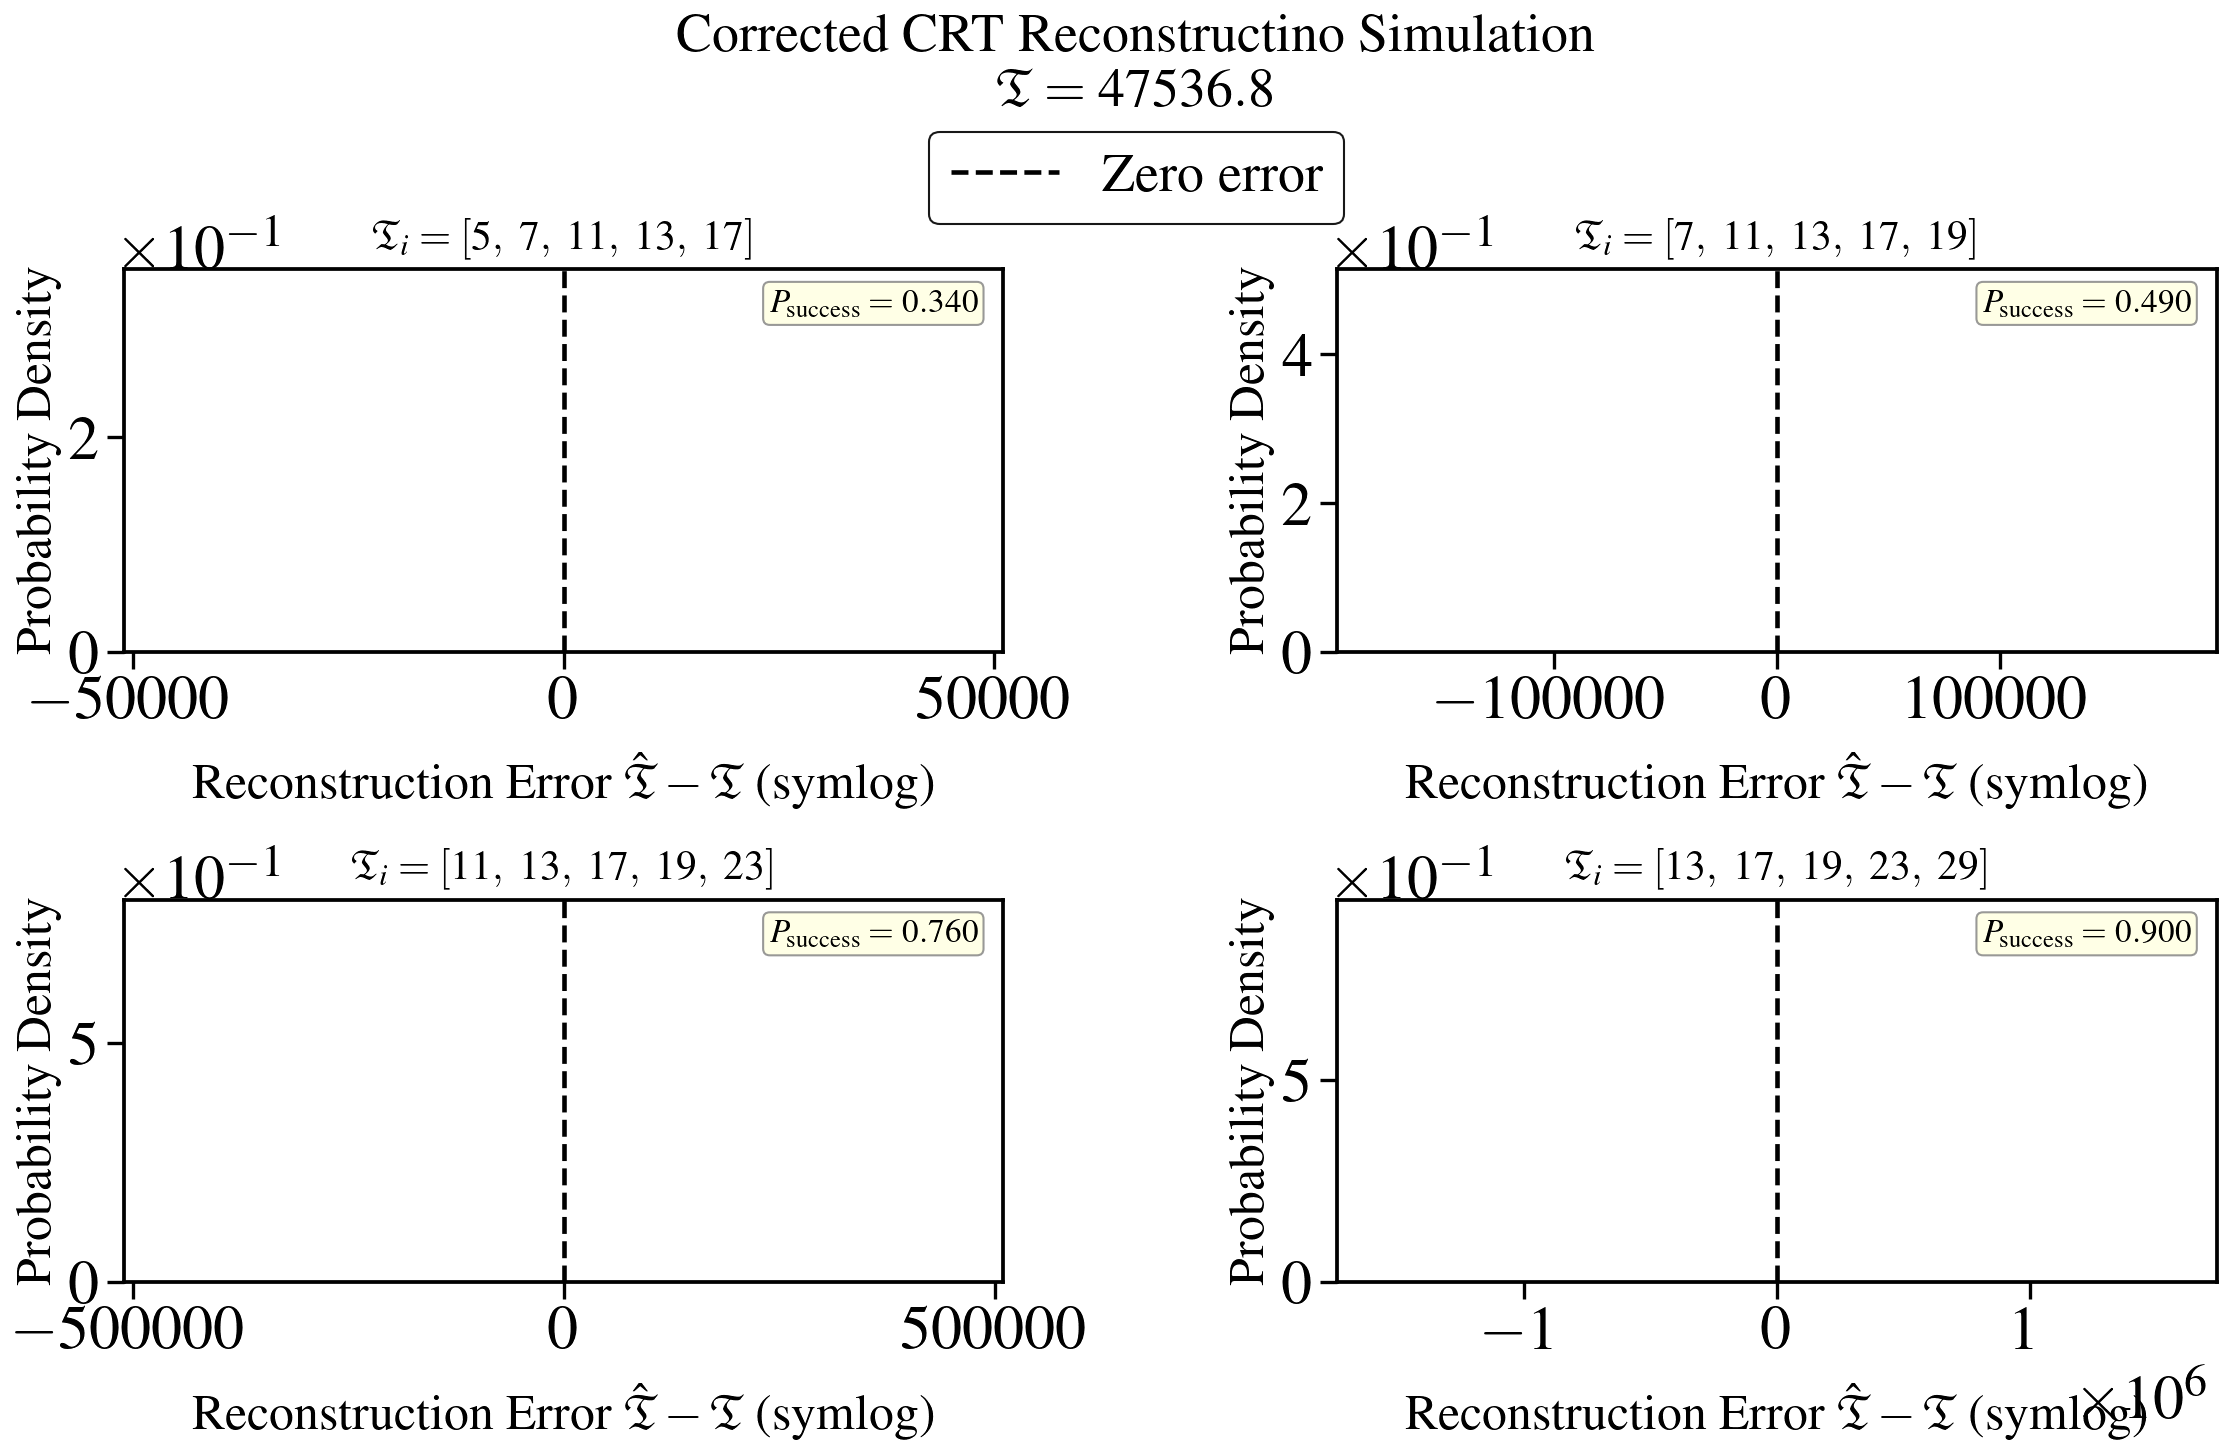

In [65]:
def traditional_crt(r_tilde, moduli):
    M = reduce(lcm, moduli)
    result = 0
    deltas = []
    for r, m in zip(r_tilde, moduli):
        r_rounded = round(r)
        r_int     = r_rounded % m
        deltas.append(r - r_rounded)
        Mi = M // m
        result += r_int * Mi * pow(Mi, -1, m)
    return result % M + sum(deltas) / len(deltas)

def popt_pdf(T, N_param):
    alpha = np.pi / N_param
    T     = np.asarray(T, dtype=float)
    num   = (1.0 + np.cos(N_param * T)) * (1.0 + np.cos(T))
    den   = (np.cos(T) - np.cos(alpha))**2
    lim   = N_param**2 * (1.0 + np.cos(T)) / (2.0 * np.sin(alpha)**2)
    near  = np.abs(den) < 1e-12
    return np.where(near, lim, np.maximum(num / np.where(near, 1.0, den), 0.0))

_popt_cache = {}

def sample_popt(N_param, size, rng, n_grid=400000):
    if N_param not in _popt_cache:
        T_grid = np.linspace(-np.pi + 1e-8, np.pi - 1e-8, n_grid)
        pdf    = popt_pdf(T_grid, N_param)
        cdf    = np.cumsum(pdf) * (T_grid[1] - T_grid[0])
        cdf   /= cdf[-1]
        _popt_cache[N_param] = (T_grid, cdf)
    T_grid, cdf = _popt_cache[N_param]
    return np.interp(rng.uniform(size=size), cdf, T_grid)

N_true    = 47536.8
N_trials  = 100
threshold = 0.25   # gcd of any distinct primes = 1, so tau* = 1/4

prime_sets = [
    [5,  7, 11, 13, 17],
    [7, 11, 13, 17, 19],
    [11, 13, 17, 19, 23],
    [13, 17, 19, 23, 29]
]

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
plt.subplots_adjust(hspace=0.65, wspace=0.38, top=0.80)
rng = np.random.default_rng(42)

legend_handle = None
linthresh = 0.5   # linear region of symlog: |error| < 0.5 is "success"

for idx, moduli_set in enumerate(prime_sets):
    M_lcm_set      = reduce(lcm, moduli_set)
    moduli_str_set = '[' + ',\\ '.join(str(m) for m in moduli_set) + ']'

    noise_samples = {m: sample_popt(m, N_trials, rng) for m in moduli_set}

    errors = []
    for trial in range(N_trials):
        rems    = [N_true % m for m in moduli_set]
        noise   = [float(noise_samples[m][trial]) for m in moduli_set]
        noisy_r = [r + n for r, n in zip(rems, noise)]
        result  = traditional_crt(noisy_r, moduli_set)
        err     = (result - N_true + M_lcm_set / 2) % M_lcm_set - M_lcm_set / 2
        errors.append(err)

    ax         = axes.flatten()[idx]
    errors_arr = np.array(errors, dtype=float)
    n_within   = int(np.sum(np.abs(errors_arr) < 0.5))
    p_success  = n_within / N_trials

    # Symlog-spaced bins: log-spaced on ± sides, meeting at ±linthresh
    max_e    = max(np.abs(errors_arr).max(), linthresh * 2)
    pos_edges = np.logspace(np.log10(linthresh), np.log10(max_e * 1.2), 30)
    bins      = np.concatenate([-pos_edges[::-1], pos_edges])

    ax.hist(errors_arr, bins=bins, color='steelblue', edgecolor='white',
            linewidth=0.3, alpha=0.85, density=True)
    line = ax.axvline(0, color='black', linestyle='--', linewidth=2.2,
                      label='Zero error')
    if legend_handle is None:
        legend_handle = line

    ax.yaxis.set_major_formatter(plt.matplotlib.ticker.ScalarFormatter(useMathText=True))
    ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))

    stats_text = rf'$P_{{\mathrm{{success}}}} = {p_success:.3f}$'
    ax.text(0.97, 0.95, stats_text, transform=ax.transAxes,
            ha='right', va='top', fontsize=16,
            bbox=dict(boxstyle='round,pad=0.2', facecolor='lightyellow',
                      edgecolor='gray', alpha=0.8))

    ax.set_title(rf'$\mathfrak{{T}}_i = {moduli_str_set}$', pad=10, fontsize=20)
    ax.set_xlabel(r'Reconstruction Error $\hat{\mathfrak{T}} - \mathfrak{T}$ (symlog)', labelpad=10)
    ax.set_ylabel('Probability Density')

fig.suptitle(
    rf'Corrected CRT Reconstructino Simulation'
    + '\n' +
    rf'$\mathfrak{{T}} = {N_true}$',
    fontsize=26, fontweight='bold', y=0.97
)
fig.legend(handles=[legend_handle], loc='upper center',
           bbox_to_anchor=(0.5, 0.91), ncol=1, framealpha=0.9, fontsize=26)

fig.savefig('CRT_popt_simulation.svg', bbox_inches='tight')
fig.savefig('CRT_popt_simulation.pdf', bbox_inches='tight')
plt.show()


KeyboardInterrupt: 

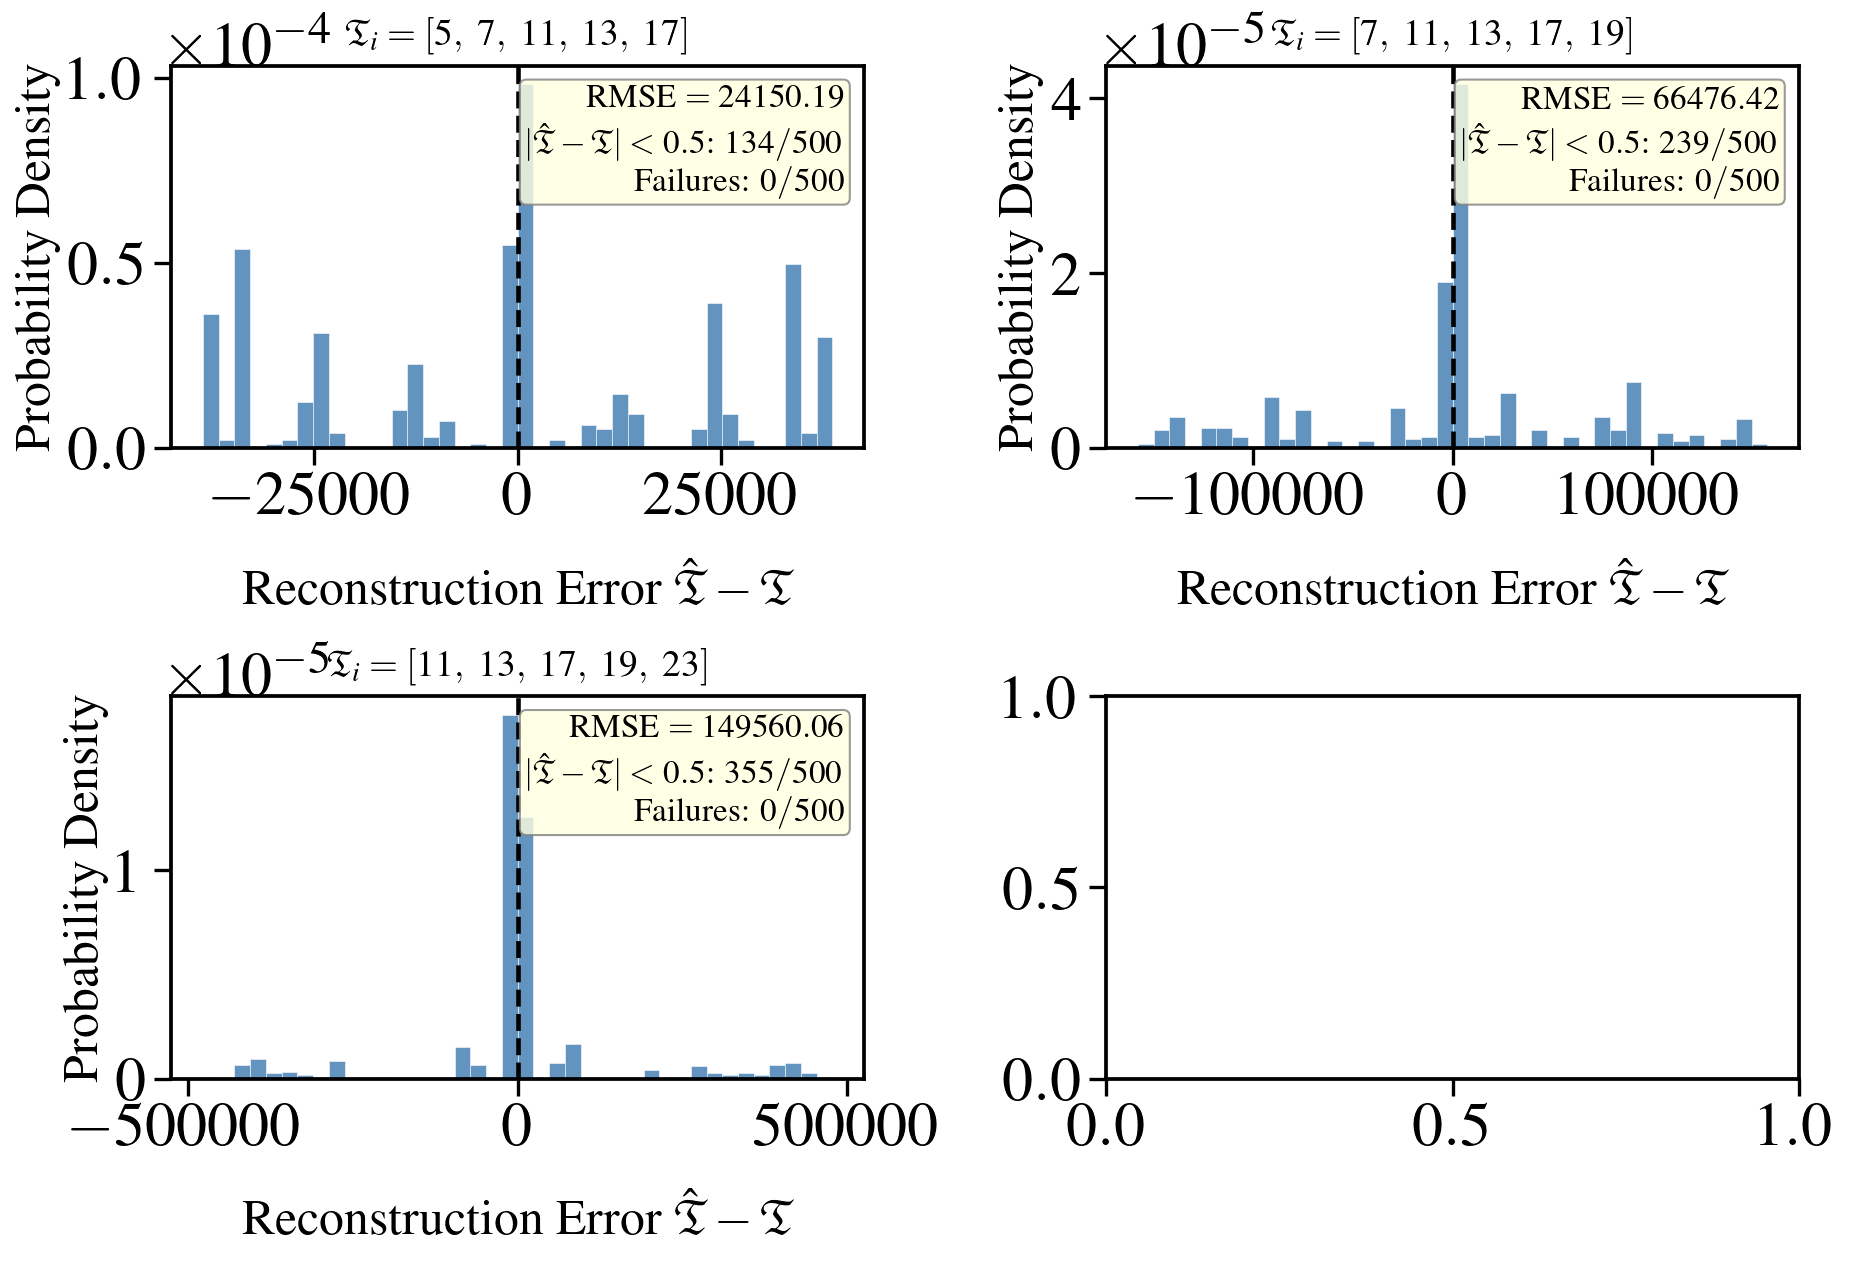

In [66]:
# Robust CRT with P_opt noise — sliding prime windows
# Requires: robust_crt_int (cell 97jku693iui), sample_popt / popt_pdf (cell 2617386f)

N_true_r    = 47536.8
N_trials_r  = 500

prime_sets_r = [
    [5,  7, 11, 13, 17],
    [7, 11, 13, 17, 19],
    [11, 13, 17, 19, 23],
    [13, 17, 19, 23, 29],
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
plt.subplots_adjust(hspace=0.65, wspace=0.35, top=0.80)
rng_r = np.random.default_rng(42)

legend_handle_r = None

for idx, moduli_set in enumerate(prime_sets_r):
    M_lcm_set      = reduce(lcm, moduli_set)
    moduli_str_set = '[' + ',\\ '.join(str(m) for m in moduli_set) + ']'

    noise_samples = {m: sample_popt(m, N_trials_r, rng_r) for m in moduli_set}

    errors   = []
    n_failed = 0
    for trial in range(N_trials_r):
        rems    = [N_true_r % m for m in moduli_set]
        noise   = [float(noise_samples[m][trial]) for m in moduli_set]
        noisy_r = [r + n for r, n in zip(rems, noise)]
        result  = robust_crt_int(noisy_r, moduli_set)
        if result is not None:
            err = (result - N_true_r + M_lcm_set / 2) % M_lcm_set - M_lcm_set / 2
            errors.append(err)
        else:
            n_failed += 1

    ax    = axes.flatten()[idx]
    color = 'steelblue'

    errors_arr = np.array(errors, dtype=float)
    rmse       = np.sqrt(np.mean(errors_arr ** 2))
    n_within   = int(np.sum(np.abs(errors_arr) < 0.5))

    ax.hist(errors_arr, bins=40, color=color, edgecolor='white',
            linewidth=0.3, alpha=0.85, density=True)
    line = ax.axvline(0, color='black', linestyle='--', linewidth=2.2,
                      label='Zero error')
    if legend_handle_r is None:
        legend_handle_r = line

    ax.yaxis.set_major_formatter(plt.matplotlib.ticker.ScalarFormatter(useMathText=True))
    ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))

    stats_text = (rf'RMSE $= {rmse:.2f}$' + '\n' +
                  rf'$|\hat{{\mathfrak{{T}}}}-\mathfrak{{T}}|<0.5$: ${n_within}/{N_trials_r}$' + '\n' +
                  rf'Failures: ${n_failed}/{N_trials_r}$')
    ax.text(0.97, 0.95, stats_text, transform=ax.transAxes,
            ha='right', va='top', fontsize=16,
            bbox=dict(boxstyle='round,pad=0.2', facecolor='lightyellow',
                      edgecolor='gray', alpha=0.8))

    ax.set_title(rf'$\mathfrak{{T}}_i = {moduli_str_set}$', pad=10, fontsize=18)
    ax.set_xlabel(r'Reconstruction Error $\hat{\mathfrak{T}} - \mathfrak{T}$', labelpad=20)
    ax.set_ylabel('Probability Density')

fig.suptitle(
    rf'Robust CRT, $P_{{\mathrm{{opt}}}}$ noise ($N = \mathfrak{{T}}_i$ per modulus)'
    + '\n' +
    rf'$\mathfrak{{T}} = {N_true_r}$',
    fontsize=26, fontweight='bold', y=0.97
)
fig.legend(handles=[legend_handle_r], loc='upper center',
           bbox_to_anchor=(0.5, 0.91), ncol=1, framealpha=0.9, fontsize=26)

fig.savefig('CRT_robust_popt_simulation.svg', bbox_inches='tight')
fig.savefig('CRT_robust_popt_simulation.pdf', bbox_inches='tight')
plt.show()

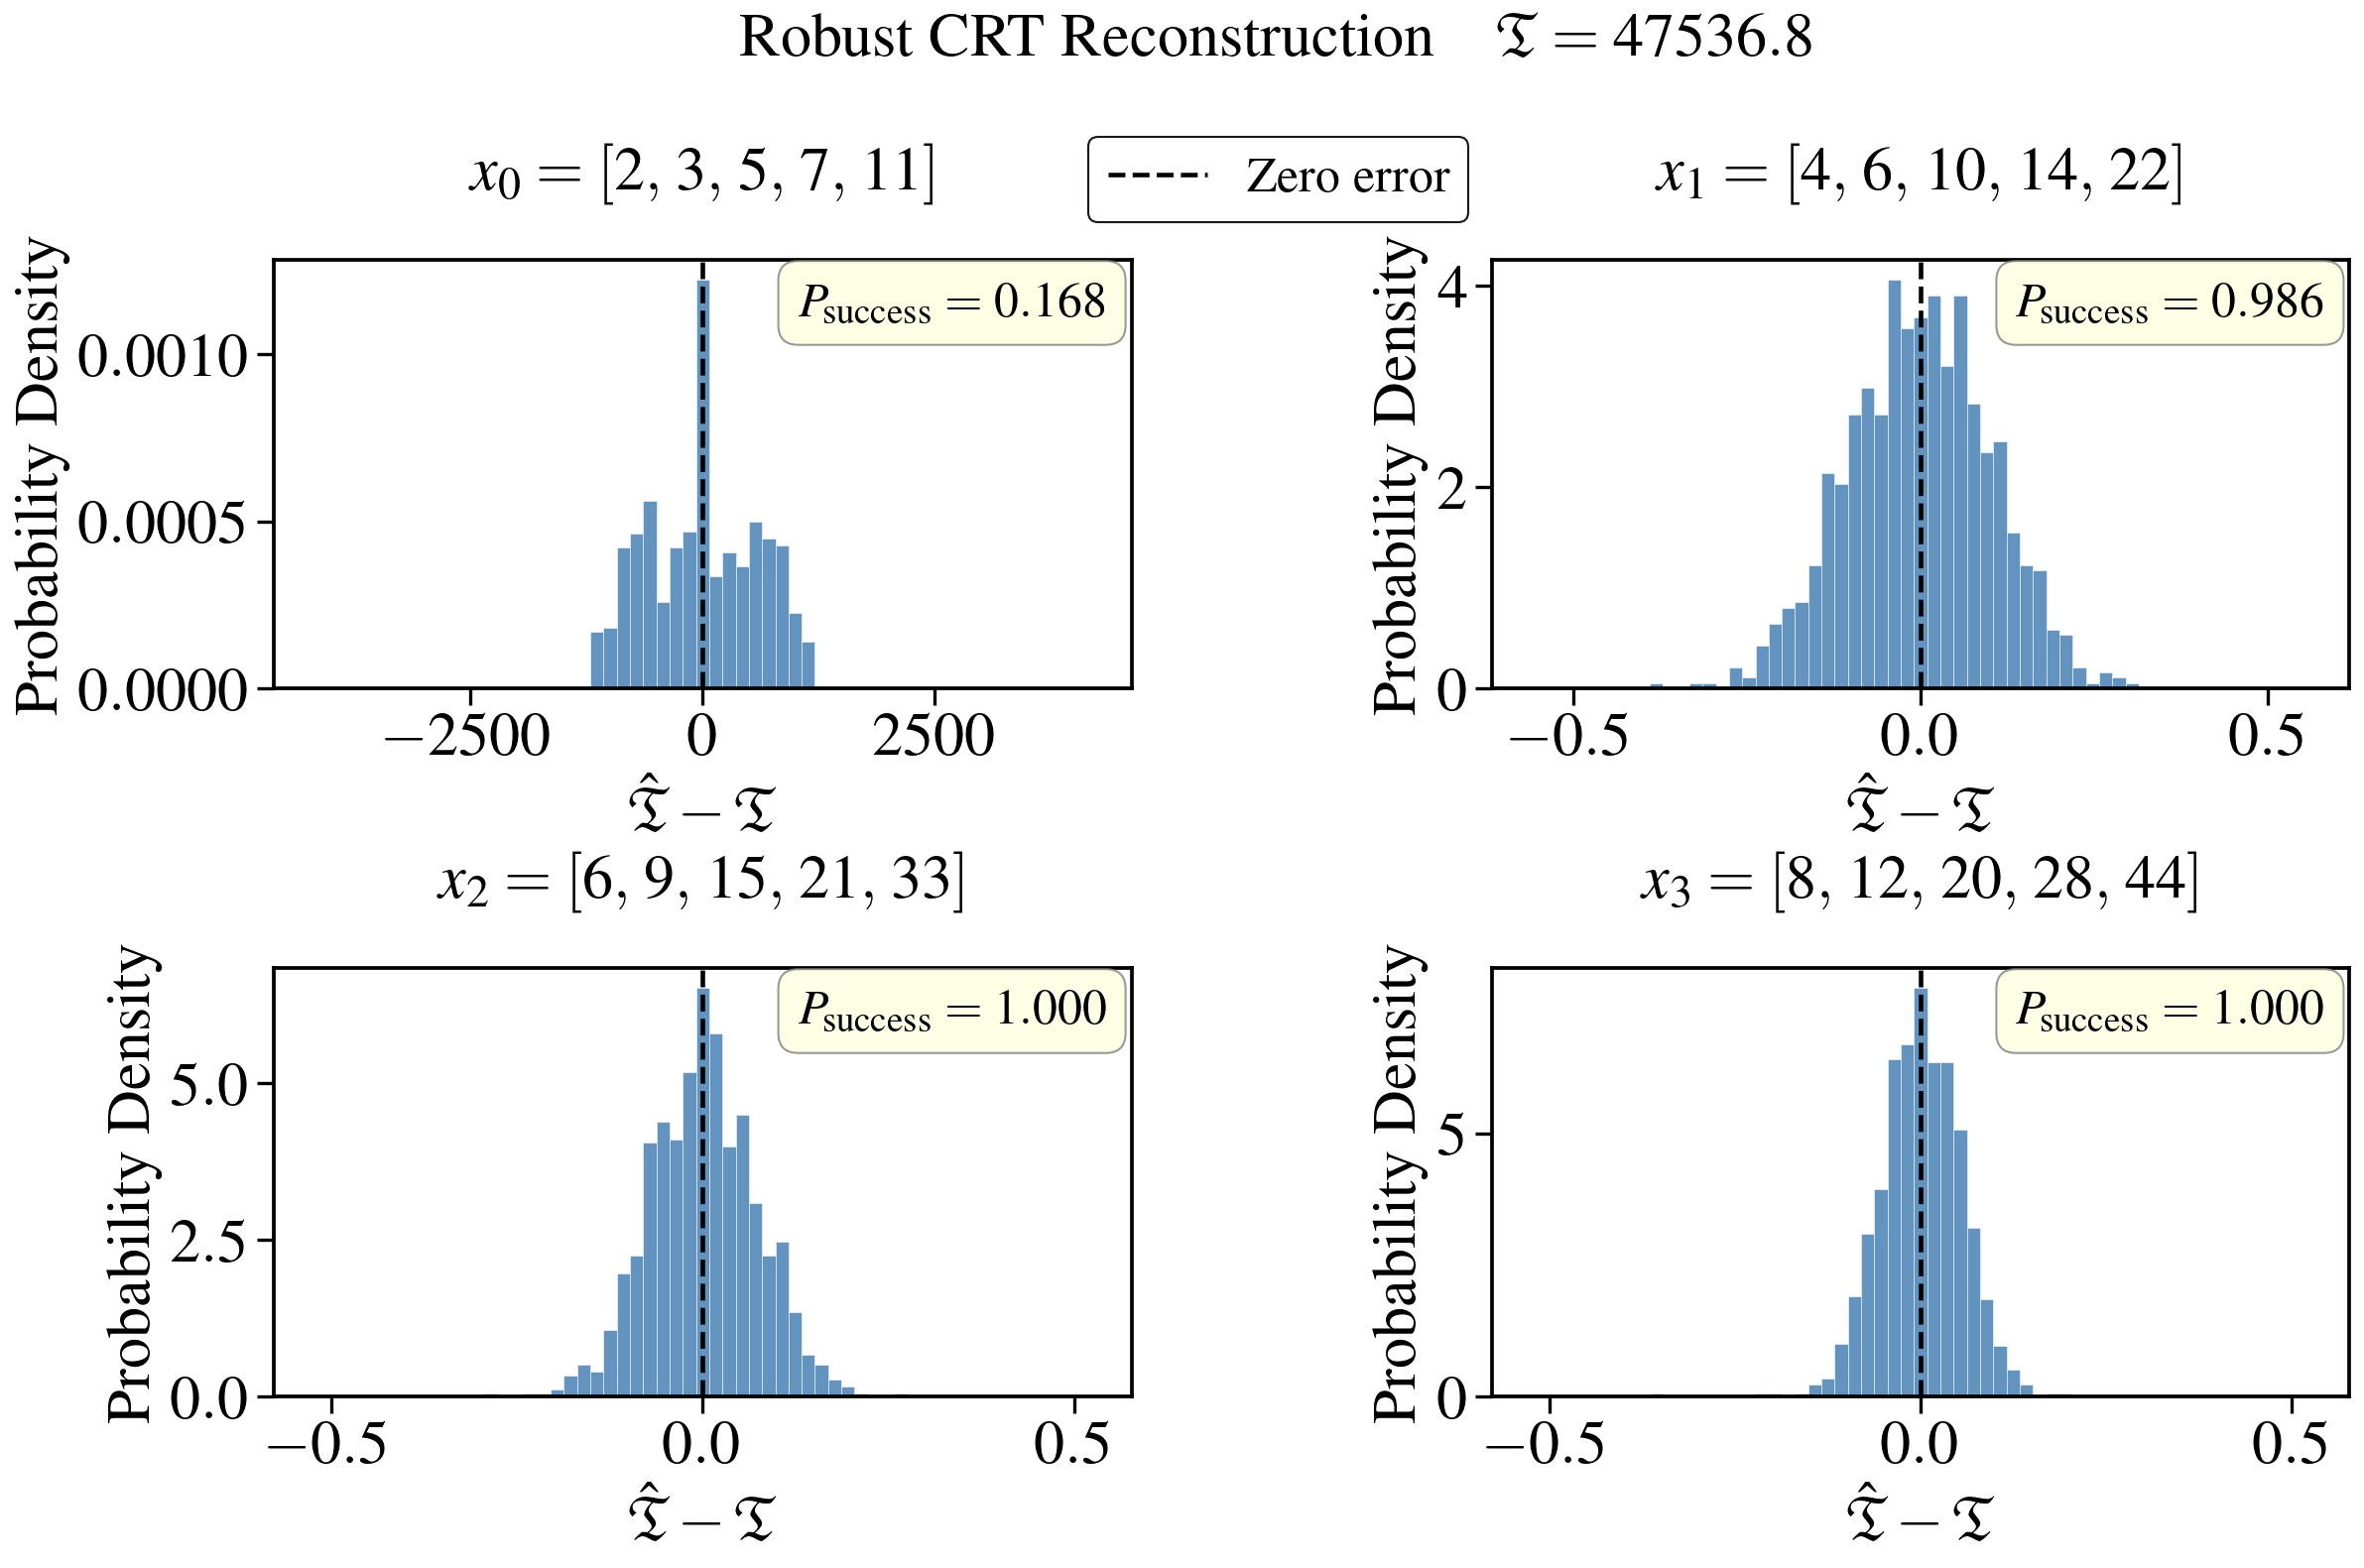

In [85]:
import numpy as np
import matplotlib.pyplot as plt
from math import gcd, prod, lcm
from functools import reduce
import matplotlib as mpl

mpl.rcParams.update({
    'text.usetex'         : True,
    'text.latex.preamble' : r'\usepackage{mathptmx} \usepackage{amssymb}',
    'font.family'         : 'serif',
    'font.size'           : 28,
    'axes.titlesize'      : 24,
    'axes.labelsize'      : 24,
    'xtick.labelsize'     : 30,
    'ytick.labelsize'     : 30,
    'legend.fontsize'     : 24,
    'axes.linewidth'      : 1.8,
    'figure.dpi'          : 150,
})

def popt_pdf(phi, N):
    phi   = np.asarray(phi, dtype=float)
    alpha = np.pi / N
    num   = (1.0 + np.cos(N * phi)) * (1.0 + np.cos(phi))
    den   = (1.0 - np.cos(phi + alpha)) * (1.0 - np.cos(phi - alpha))
    lim   = N**2 * (1.0 + np.cos(phi)) / (2.0 * np.sin(alpha)**2)
    near  = np.abs(den) < 1e-12
    return np.where(near, lim, np.maximum(num / np.where(near, 1.0, den), 0.0))

_popt_cache = {}

def sample_popt(N, size, rng, n_grid=400_000):
    if N not in _popt_cache:
        phi_grid = np.linspace(-np.pi + 1e-8, np.pi - 1e-8, n_grid)
        pdf      = popt_pdf(phi_grid, N)
        cdf      = np.cumsum(pdf) * (phi_grid[1] - phi_grid[0])
        cdf     /= cdf[-1]
        _popt_cache[N] = (phi_grid, cdf)
    phi_grid, cdf = _popt_cache[N]
    return np.interp(rng.uniform(size=size), cdf, phi_grid)

base_primes  = np.array([2, 3, 5, 7, 11])   # omega_i = 2*pi / base_prime_i (fixed)
prime_sets_r = [
    np.array([2,  3, 5, 7, 11]),
    2*np.array([2,  3, 5, 7, 11]),
    3*np.array([2,  3, 5, 7, 11]),
    4*np.array([2,  3, 5, 7, 11]),
]

N_true   = 47536.8
N_trials = 1000
rng      = np.random.default_rng(42)

fig, axes = plt.subplots(2, 2, figsize=(18, 11))
plt.subplots_adjust(hspace=0.65, wspace=0.42, top=0.82)

legend_handle = None

for idx, moduli in enumerate(prime_sets_r):
    M_lcm = reduce(lcm, moduli)

    # Sample phi ~ P_opt(phi; N=m) using the actual (scaled) modulus as N
    noise_samples = {m: sample_popt(m, N_trials, rng) for m in moduli}

    errors   = []
    n_failed = 0
    for trial in range(N_trials):
        rems    = [N_true % m for m in moduli]
        # omega_i = 2*pi / base_prime_i (always from [2,3,5,7,11])
        # delta_T = phi / omega_i = phi * base_prime_i / (2*pi)
        noise   = [float(noise_samples[m][trial]) * bp / (2 * np.pi)
                   for m, bp in zip(moduli, base_primes)]
        noisy_r = [r + n for r, n in zip(rems, noise)]
        result  = robust_crt_int(noisy_r, moduli)   # cell 97jku693iui
        if result is not None:
            err = (result - N_true + M_lcm / 2) % M_lcm - M_lcm / 2
            errors.append(err)
        else:
            n_failed += 1

    ax         = axes.flatten()[idx]
    errors_arr = np.array(errors, dtype=float)
    n_within   = int(np.sum(np.abs(errors_arr) < 0.5))
    p_success  = n_within / N_trials

    # MAD-based bin range: robust to any number/magnitude of outliers.
    med   = np.median(errors_arr)
    mad   = max(np.median(np.abs(errors_arr - med)) * 1.4826, 1e-9)
    max_e = max(5 * mad, 0.5)
    bins  = np.linspace(-max_e * 1.05, max_e * 1.05, 60)

    ax.hist(errors_arr, bins=bins,
            color='steelblue', edgecolor='white', linewidth=0.3, alpha=0.85, density=True)
    line = ax.axvline(0, color='black', linestyle='--', linewidth=2.2,
                      label='Zero error')
    if legend_handle is None:
        legend_handle = line

    moduli_str = r'[' + r',\,'.join(str(m) for m in moduli) + r']'
    stats_text = rf'$P_{{\mathrm{{success}}}} = {p_success:.3f}$'
    ax.text(0.97, 0.95, stats_text, transform=ax.transAxes,
            ha='right', va='top', fontsize=24,
            bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow',
                      edgecolor='gray', alpha=0.8))

    ax.set_title(rf'$x_{{{idx}}} = {moduli_str}$', pad=34, fontsize=30)
    ax.set_xlabel(r'$\hat{\mathfrak{T}} - \mathfrak{T}$', labelpad=10, fontsize=30)
    ax.set_ylabel('Probability Density', fontsize=30)

fig.suptitle(
    r'Robust CRT Reconstruction'
    + rf'\quad $\mathfrak{{T}} = {N_true}$',
    fontsize=30, fontweight='bold', y=0.97
)
fig.legend(handles=[legend_handle], loc='upper center',
           bbox_to_anchor=(0.5, 0.91), ncol=1, framealpha=0.9, fontsize=24)

fig.savefig('CRT_robust_popt_simulation.svg', bbox_inches='tight')
fig.savefig('CRT_robust_popt_simulation.pdf', bbox_inches='tight')
plt.show()


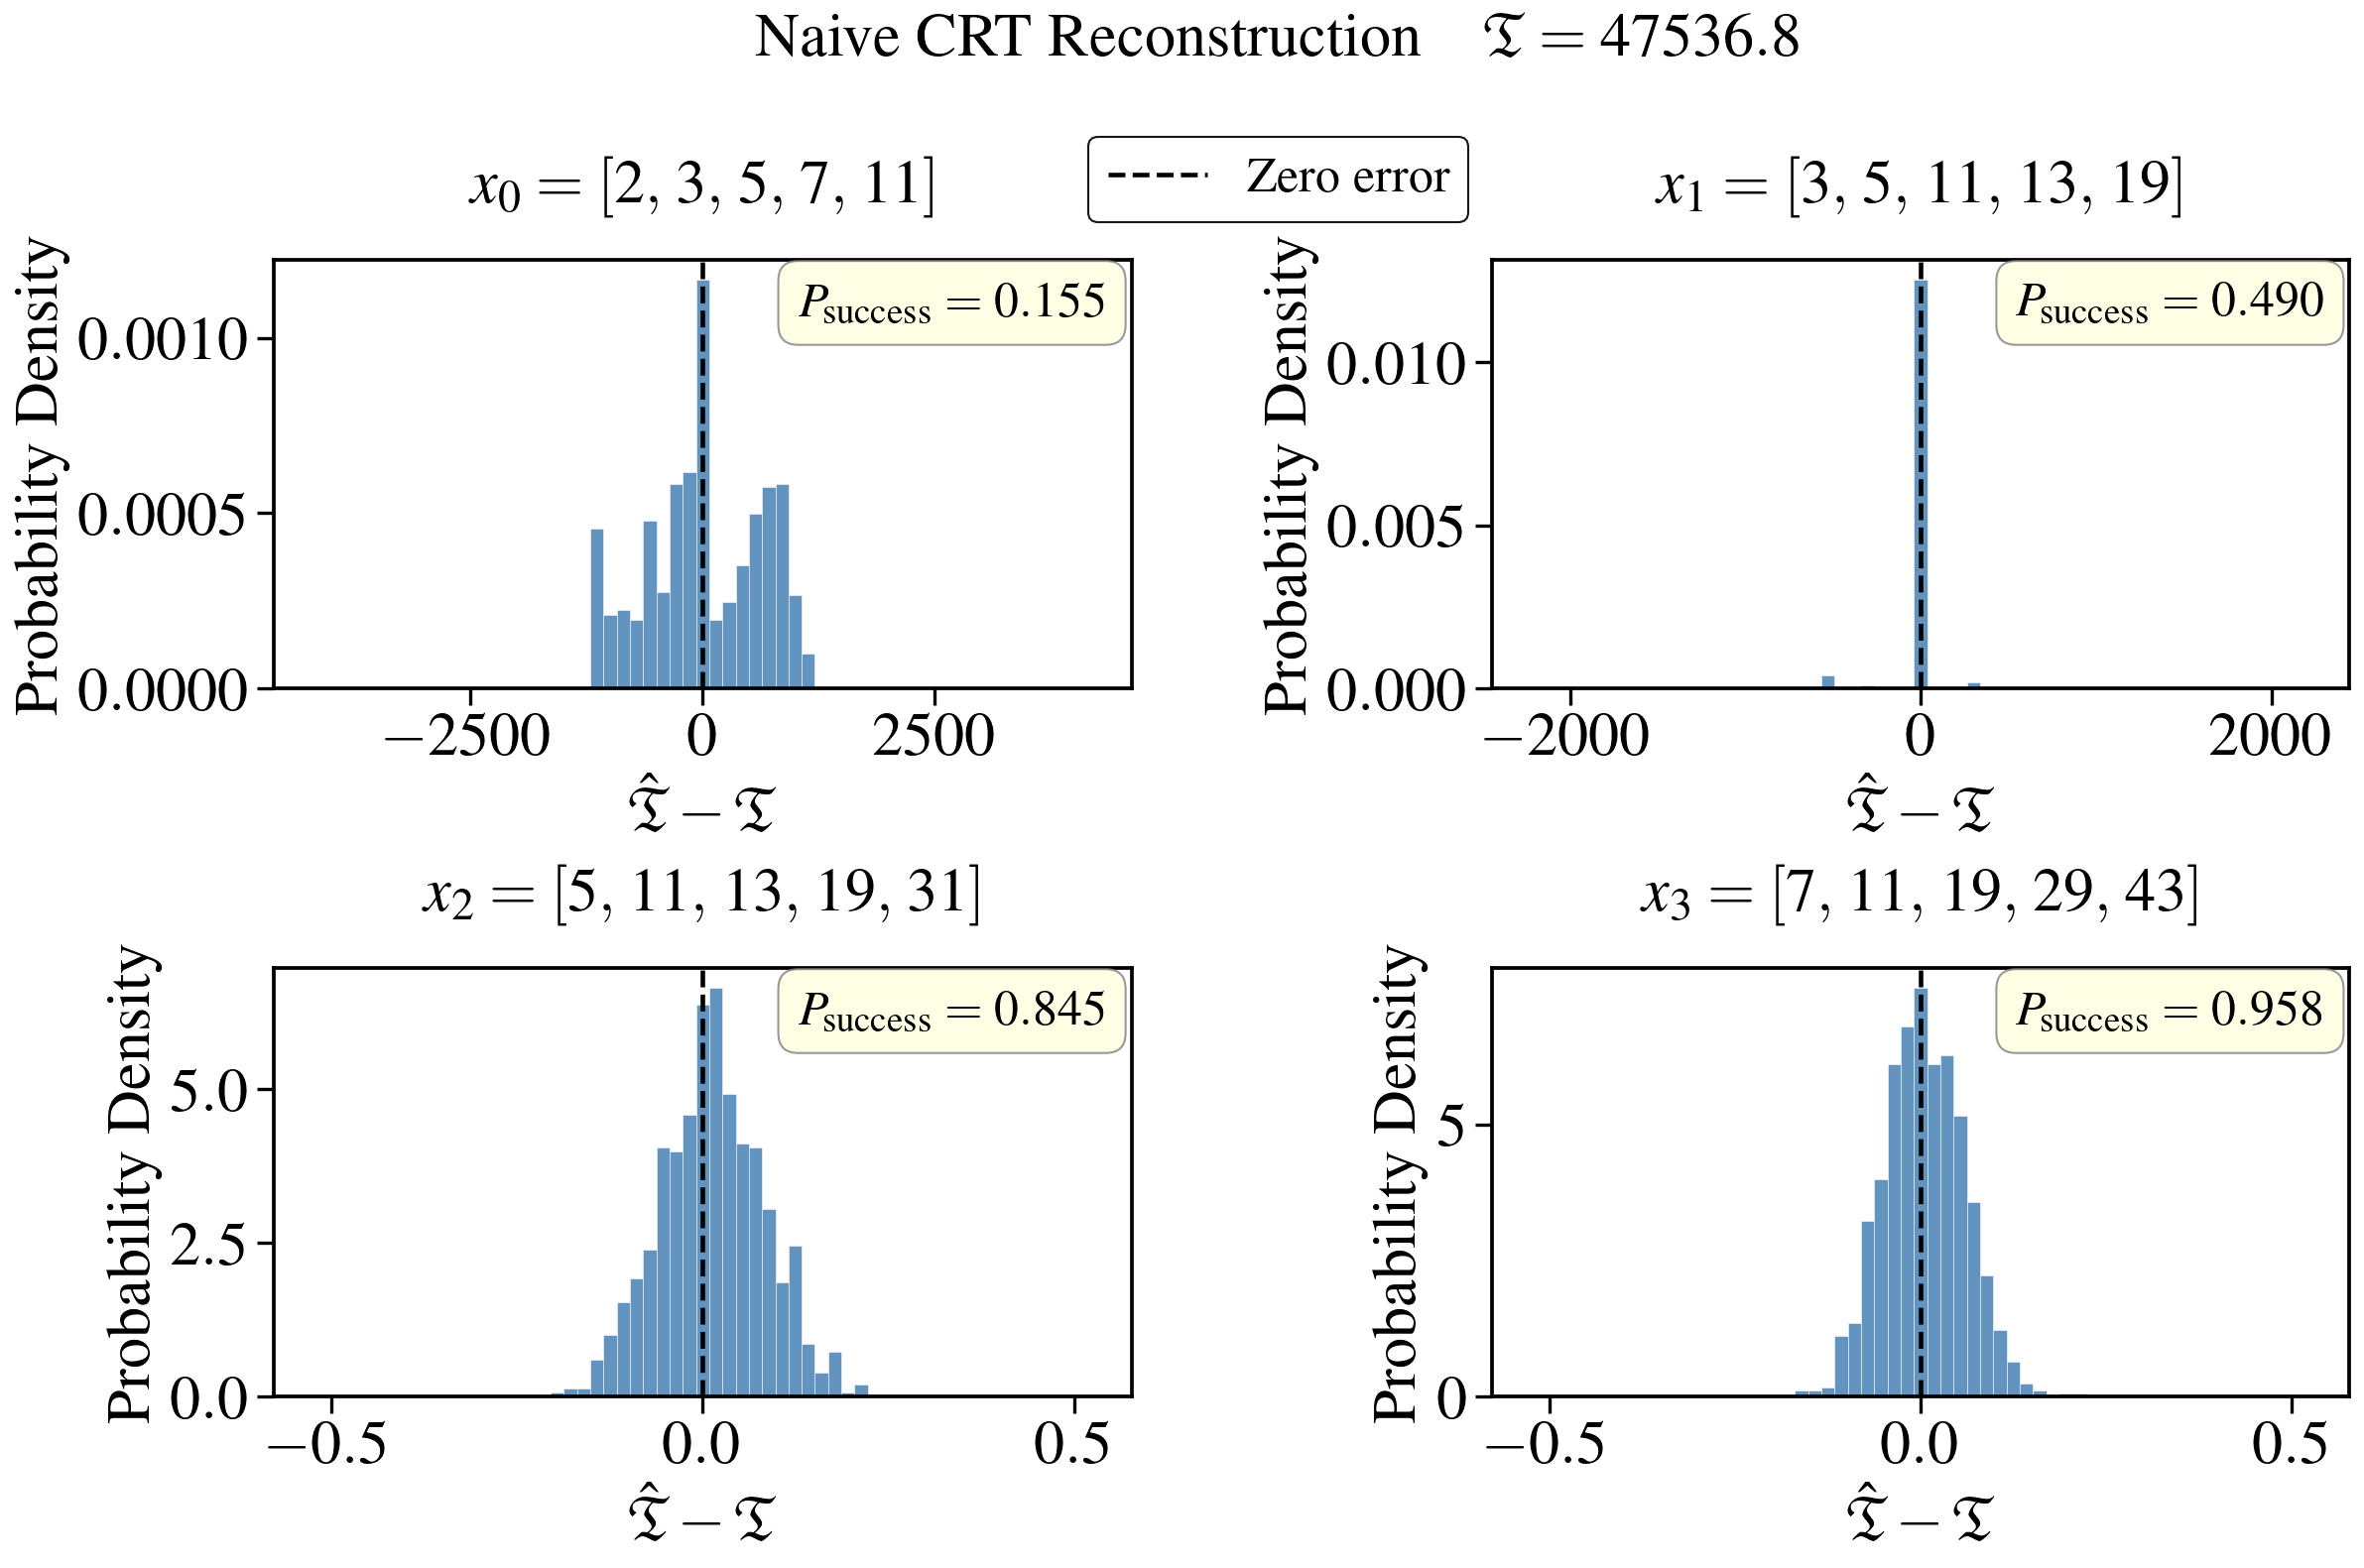

In [86]:
import numpy as np
import matplotlib.pyplot as plt
from math import gcd, prod, lcm
from functools import reduce
import matplotlib as mpl

mpl.rcParams.update({
    'text.usetex'         : True,
    'text.latex.preamble' : r'\usepackage{mathptmx} \usepackage{amssymb}',
    'font.family'         : 'serif',
    'font.size'           : 28,
    'axes.titlesize'      : 24,
    'axes.labelsize'      : 24,
    'xtick.labelsize'     : 30,
    'ytick.labelsize'     : 30,
    'legend.fontsize'     : 24,
    'axes.linewidth'      : 1.8,
    'figure.dpi'          : 150,
})

def traditional_crt(r_tilde, moduli):
    moduli = [int(m) for m in moduli]
    M_lcm  = reduce(lcm, moduli)
    result = 0
    deltas = []
    for r, m in zip(r_tilde, moduli):
        r_rounded = round(r)
        r_int     = r_rounded % m
        deltas.append(r - r_rounded)
        Mi     = M_lcm // m
        result += r_int * Mi * pow(Mi, -1, m)
    return result % M_lcm + sum(deltas) / len(deltas)

def popt_pdf(phi, N):
    phi   = np.asarray(phi, dtype=float)
    alpha = np.pi / N
    num   = (1.0 + np.cos(N * phi)) * (1.0 + np.cos(phi))
    den   = (1.0 - np.cos(phi + alpha)) * (1.0 - np.cos(phi - alpha))
    lim   = N**2 * (1.0 + np.cos(phi)) / (2.0 * np.sin(alpha)**2)
    near  = np.abs(den) < 1e-12
    return np.where(near, lim, np.maximum(num / np.where(near, 1.0, den), 0.0))

_popt_cache_naive = {}

def sample_popt_naive(N, size, rng, n_grid=400_000):
    if N not in _popt_cache_naive:
        phi_grid = np.linspace(-np.pi + 1e-8, np.pi - 1e-8, n_grid)
        pdf      = popt_pdf(phi_grid, N)
        cdf      = np.cumsum(pdf) * (phi_grid[1] - phi_grid[0])
        cdf     /= cdf[-1]
        _popt_cache_naive[N] = (phi_grid, cdf)
    phi_grid, cdf = _popt_cache_naive[N]
    return np.interp(rng.uniform(size=size), cdf, phi_grid)

base_primes  = np.array([2, 3, 5, 7, 11])
prime_sets_r = [
    np.array([2,  3, 5, 7, 11]),
    np.array([3,  5, 11, 13, 19]),
    np.array([5, 11, 13, 19, 31]),
    np.array([7, 11, 19, 29, 43]),
]

N_true   = 47536.8
N_trials = 1000
rng      = np.random.default_rng(42)

fig, axes = plt.subplots(2, 2, figsize=(18, 11))
plt.subplots_adjust(hspace=0.65, wspace=0.42, top=0.82)

legend_handle = None

for idx, moduli in enumerate(prime_sets_r):
    M_lcm = reduce(lcm, moduli)

    noise_samples = {m: sample_popt_naive(m, N_trials, rng) for m in moduli}

    errors = []
    for trial in range(N_trials):
        rems    = [N_true % m for m in moduli]
        # omega_i = 2*pi / base_prime_i (fixed); delta_T = phi * base_prime_i / (2*pi)
        noise   = [float(noise_samples[m][trial]) * bp / (2 * np.pi)
                   for m, bp in zip(moduli, base_primes)]
        noisy_r = [r + n for r, n in zip(rems, noise)]
        result  = traditional_crt(noisy_r, moduli)
        err     = (result - N_true + M_lcm / 2) % M_lcm - M_lcm / 2
        errors.append(err)

    ax         = axes.flatten()[idx]
    errors_arr = np.array(errors, dtype=float)
    n_within   = int(np.sum(np.abs(errors_arr) < 0.5))
    p_success  = n_within / N_trials

    # MAD-based bin range: robust to any fraction of large-error outliers.
    med   = np.median(errors_arr)
    mad   = max(np.median(np.abs(errors_arr - med)) * 1.4826, 1e-9)
    max_e = max(5 * mad, 0.5)
    bins  = np.linspace(-max_e * 1.05, max_e * 1.05, 60)
    ax.hist(errors_arr, bins=bins,
            color='steelblue', edgecolor='white', linewidth=0.3, alpha=0.85, density=True)

    line = ax.axvline(0, color='black', linestyle='--', linewidth=2.2,
                      label='Zero error')
    if legend_handle is None:
        legend_handle = line

    moduli_str = r'[' + r',\,'.join(str(m) for m in moduli) + r']'
    stats_text = rf'$P_{{\mathrm{{success}}}} = {p_success:.3f}$'
    ax.text(0.97, 0.95, stats_text, transform=ax.transAxes,
            ha='right', va='top', fontsize=24,
            bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow',
                      edgecolor='gray', alpha=0.8))

    ax.set_title(rf'$x_{{{idx}}} = {moduli_str}$', pad=28, fontsize=30)
    ax.set_xlabel(r'$\hat{\mathfrak{T}} - \mathfrak{T}$', labelpad=10, fontsize=30)
    ax.set_ylabel('Probability Density', fontsize=30)

fig.suptitle(
    r'Naive CRT Reconstruction'
    + rf'\quad $\mathfrak{{T}} = {N_true}$',
    fontsize=30, fontweight='bold', y=0.97
)
fig.legend(handles=[legend_handle], loc='upper center',
           bbox_to_anchor=(0.5, 0.91), ncol=1, framealpha=0.9, fontsize=24)

fig.savefig('CRT_naive_popt_simulation.svg', bbox_inches='tight')
fig.savefig('CRT_naive_popt_simulation.pdf', bbox_inches='tight')
plt.show()


N= 5: integral of shape =     1.0000   pi/(4N^3) = 0.006283
N= 7: integral of shape =     1.0000   pi/(4N^3) = 0.002290
N=11: integral of shape =     1.0000   pi/(4N^3) = 0.000590
N=13: integral of shape =     1.0000   pi/(4N^3) = 0.000357
N=17: integral of shape =     1.0000   pi/(4N^3) = 0.000160
N=19: integral of shape =     1.0000   pi/(4N^3) = 0.000115
N=23: integral of shape =     1.0000   pi/(4N^3) = 0.000065
N=29: integral of shape =     1.0000   pi/(4N^3) = 0.000032


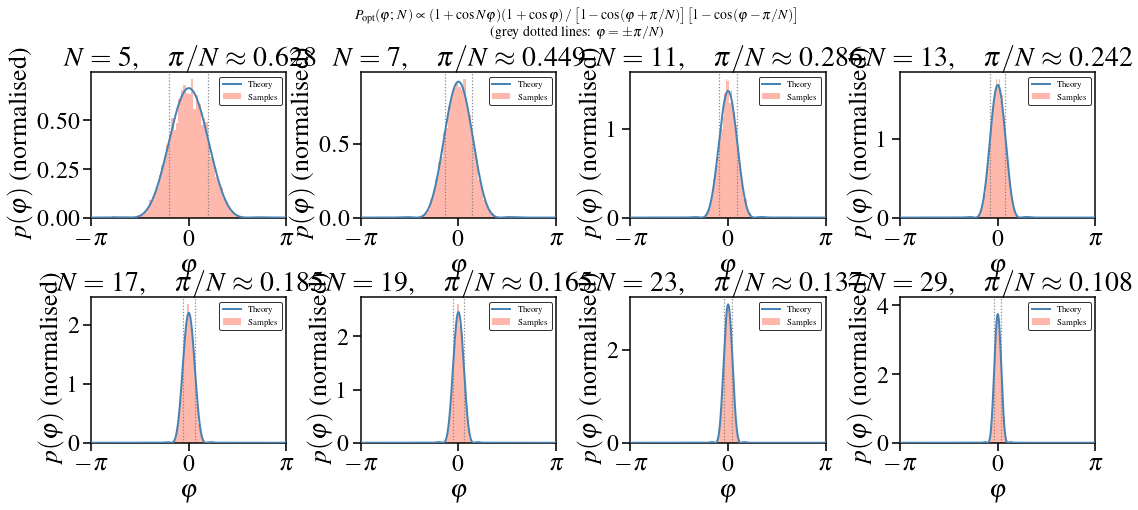

In [20]:
# Verify P_opt(phi; N) — plot normalized PDF for every prime in prime_sets_r
# and overlay 5000 inverse-CDF samples as a histogram.

all_primes = sorted({p for ps in prime_sets_r for p in ps})   # [5,7,11,13,17,19,23,29]
phi_grid   = np.linspace(-np.pi + 1e-6, np.pi - 1e-6, 200_000)
rng_v      = np.random.default_rng(0)

fig, axes = plt.subplots(2, 4, figsize=(18, 7))
plt.subplots_adjust(hspace=0.55, wspace=0.38, top=0.86)

for ax, N in zip(axes.flatten(), all_primes):
    alpha = np.pi / N

    # Theoretical curve — normalize numerically so area = 1
    pdf  = popt_pdf(phi_grid, N)
    norm = np.trapz(pdf, phi_grid)
    ax.plot(phi_grid, pdf / norm, color='steelblue', linewidth=2, label='Theory', zorder=3)

    # Samples — should match the curve
    samps = sample_popt(N, 5000, rng_v)
    ax.hist(samps, bins=60, density=True, color='tomato', alpha=0.45,
            edgecolor='none', label='Samples')

    # Mark the removable singularities phi = ±pi/N
    for sign in (+1, -1):
        ax.axvline(sign * alpha, color='gray', linestyle=':', linewidth=1.2)

    ax.set_title(rf'$N={N}$,\quad $\pi/N \approx {alpha:.3f}$')
    ax.set_xlabel(r'$\varphi$')
    ax.set_ylabel(r'$p(\varphi)$ (normalised)')
    ax.set_xlim(-np.pi, np.pi)
    ax.set_xticks([-np.pi, 0, np.pi])
    ax.set_xticklabels([r'$-\pi$', r'$0$', r'$\pi$'])
    ax.legend(fontsize=9, loc='upper right')
    print(f"N={N:2d}: integral of shape = {norm:10.4f}   pi/(4N^3) = {np.pi/(4*N**3):.6f}")

fig.suptitle(
    r'$P_{\mathrm{opt}}(\varphi;\,N) \propto '
    r'(1+\cos N\varphi)(1+\cos\varphi)\,/\,'
    r'\bigl[1-\cos(\varphi+\pi/N)\bigr]\bigl[1-\cos(\varphi-\pi/N)\bigr]$'
    '\n(grey dotted lines: ' r'$\varphi = \pm\pi/N$)',
    fontsize=14, y=0.99
)
plt.show()


In [19]:
import numpy as np
import matplotlib.pyplot as plt

def popt_pdf_raw(phi, N):
    """
    Unnormalized P_opt(phi | N) from the screenshot.
    phi is assumed to live on [-pi, pi).
    """
    phi = np.asarray(phi, dtype=float)
    a = np.pi / N

    numerator = (1 + np.cos(N * phi)) * (1 + np.cos(phi))
    denominator = (1 - np.cos(phi + a)) * (1 - np.cos(phi - a))

    with np.errstate(divide='ignore', invalid='ignore'):
        pdf = (np.pi / (4 * N**3)) * numerator / denominator

    # The formula has removable 0/0 points at phi = ± pi/N.
    # This is the analytic limiting value there.
    singular_limit = np.pi / (16 * N * np.sin(a / 2)**2)

    pdf = np.where(np.isclose(phi,  a, atol=1e-12), singular_limit, pdf)
    pdf = np.where(np.isclose(phi, -a, atol=1e-12), singular_limit, pdf)

    # Remove any numerical artifacts.
    pdf = np.where(np.isfinite(pdf), pdf, singular_limit)
    pdf = np.maximum(pdf, 0.0)

    return pdf


def make_popt_grid(N, n_grid=None):
    """
    Make a normalized numerical grid for P_opt(phi | N).
    This is useful both for plotting and inverse-CDF sampling.
    """
    if n_grid is None:
        n_grid = max(100_000, 8000 * N)

    # Midpoint grid avoids evaluating exactly at the removable singularities.
    dphi = 2 * np.pi / n_grid
    phi_grid = -np.pi + (np.arange(n_grid) + 0.5) * dphi

    pdf_raw = popt_pdf_raw(phi_grid, N)

    # Numerical normalization.
    Z = np.sum(pdf_raw) * dphi
    pdf = pdf_raw / Z

    cdf = np.cumsum(pdf) * dphi
    cdf[-1] = 1.0

    return phi_grid, pdf, cdf, dphi, Z


def popt_pdf(phi, N):
    """
    Normalized P_opt(phi | N), interpolated from a numerical grid.
    """
    phi = np.asarray(phi, dtype=float)

    # Wrap phi to [-pi, pi)
    phi_wrapped = (phi + np.pi) % (2 * np.pi) - np.pi

    phi_grid, pdf_grid, _, _, _ = make_popt_grid(N)

    return np.interp(phi_wrapped, phi_grid, pdf_grid)


def sample_popt(N, size, rng=None):
    """
    Draw samples phi ~ P_opt(phi | N) using inverse-CDF sampling.
    """
    if rng is None:
        rng = np.random.default_rng()
    elif isinstance(rng, (int, np.integer)):
        rng = np.random.default_rng(rng)

    phi_grid, pdf, cdf, dphi, Z = make_popt_grid(N)

    # Construct CDF on bin edges for inverse transform sampling.
    edges = -np.pi + np.arange(len(phi_grid) + 1) * dphi
    cdf_edges = np.concatenate([[0.0], cdf])

    u = rng.random(size)
    samples = np.interp(u, cdf_edges, edges)

    return samples

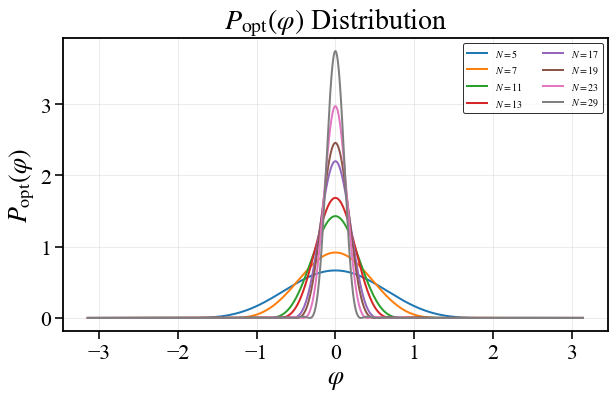

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

# ------------------------------------------------------------
# Publication-style Matplotlib settings
# ------------------------------------------------------------
plt.rcParams.update({
    # Font
    "font.family": "Times New Roman",
    "mathtext.fontset": "stix",
    "font.size": 22,

    # Axes
    "axes.labelsize": 26,
    "axes.titlesize": 28,
    "axes.linewidth": 1.8,

    # Ticks
    "xtick.labelsize": 22,
    "ytick.labelsize": 22,
    "xtick.major.size": 8,
    "ytick.major.size": 8,
    "xtick.minor.size": 4,
    "ytick.minor.size": 4,
    "xtick.major.width": 1.6,
    "ytick.major.width": 1.6,
    "xtick.minor.width": 1.2,
    "ytick.minor.width": 1.2,

    # Legend
    "legend.fontsize": 18,
    "legend.frameon": True,
    "legend.edgecolor": "black",

    # Lines
    "lines.linewidth": 3.0,

    # Saving
    "savefig.dpi": 600,
    "savefig.bbox": "tight",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

prime_sets_r = [
    [5,  7, 11, 13, 17],
    [7, 11, 13, 17, 19],
    [11, 13, 17, 19, 23],
    [13, 17, 19, 23, 29],
]

all_moduli = sorted(set(m for s in prime_sets_r for m in s))

fig, ax = plt.subplots(figsize=(9, 6))

for N in all_moduli:
    phi_grid, pdf, cdf, dphi, Z = make_popt_grid(N)
    ax.plot(phi_grid, pdf, linewidth=2, label=rf'$N={N}$')

ax.set_xlabel(r'$\varphi$')
ax.set_ylabel(r'$P_{\mathrm{opt}}(\varphi)$')
ax.set_title(r'$P_{\mathrm{opt}}(\varphi)$ Distribution')
ax.legend(ncol=2, fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('ErrorDistribution.pdf')
plt.show()


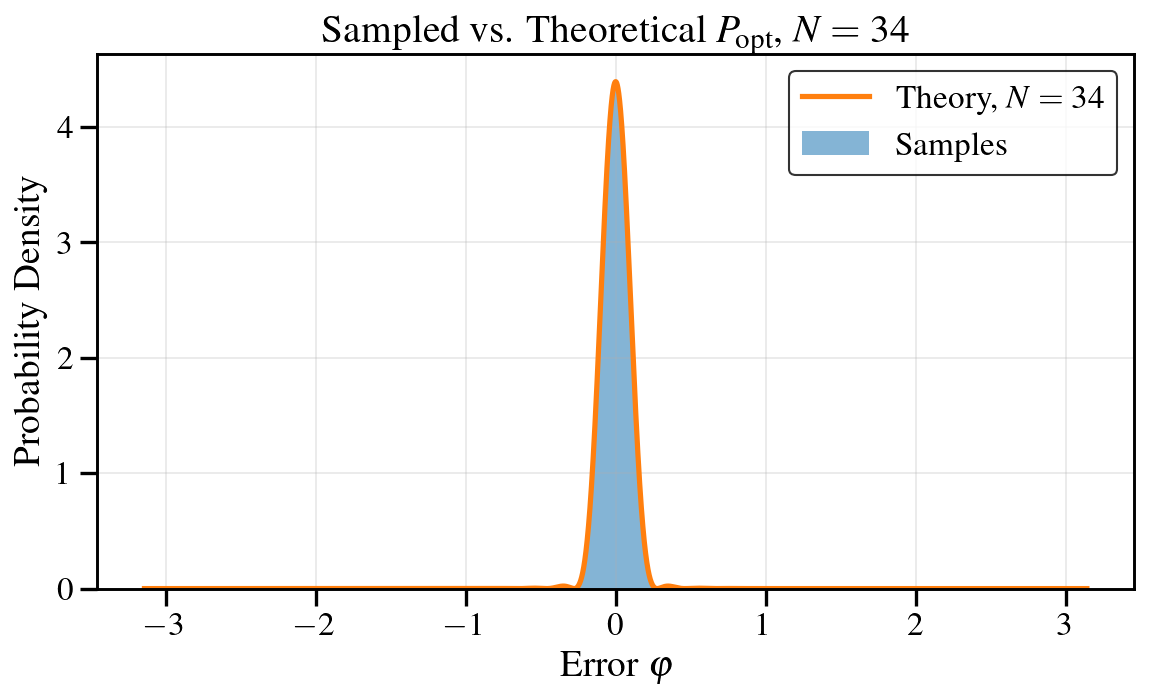

In [32]:
N = 34
rng = np.random.default_rng(42)

samples = sample_popt(N, 100_000, rng)

phi_grid, pdf, _, _, _ = make_popt_grid(N)

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(samples, bins=150, density=True, alpha=0.55, label='Samples')
ax.plot(phi_grid, pdf, linewidth=2.5, label=rf'Theory, $N={N}$')

ax.set_xlabel(r'Error $\varphi$')
ax.set_ylabel('Probability Density')
ax.set_title(rf'Sampled vs. Theoretical $P_{{\mathrm{{opt}}}}$, $N={N}$')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from math import gcd, prod, lcm
from functools import reduce
import matplotlib as mpl

mpl.rcParams.update({
    'text.usetex'         : True,
    'text.latex.preamble' : r'\usepackage{mathptmx} \usepackage{amssymb}',
    'font.family'         : 'serif',
    'font.size'           : 18,
    'axes.titlesize'      : 19,
    'axes.labelsize'      : 18,
    'xtick.labelsize'     : 16,
    'ytick.labelsize'     : 16,
    'legend.fontsize'     : 16,
    'axes.linewidth'      : 1.4,
    'figure.dpi'          : 150,
})

# P_opt(phi | t) — Eq. 10 from paper, implemented directly as written:
#
#   pi         (1 + cos N*phi)(1 + cos phi)
#  ---- * -----------------------------------------------
#  4N^3   [1 - cos(phi + pi/N)] [1 - cos(phi - pi/N)]
#
# phi is the phase error; N is the prime used for that remainder.
# The two denominator factors vanish at phi = -pi/N and phi = +pi/N
# respectively; the numerator also vanishes there (cos(N*phi)=-1),
# so both limits are finite and handled by L'Hopital below.
def popt_pdf(phi, N):
    phi   = np.asarray(phi, dtype=float)
    alpha = np.pi / N
    num   = (1.0 + np.cos(N * phi)) * (1.0 + np.cos(phi))
    den   = (1.0 - np.cos(phi + alpha)) * (1.0 - np.cos(phi - alpha))
    # L'Hopital limit at phi = ±alpha: N^2 (1 + cos phi) / (2 sin^2(alpha))
    lim   = N**2 * (1.0 + np.cos(phi)) / (2.0 * np.sin(alpha)**2)
    near  = np.abs(den) < 1e-12
    return np.where(near, lim, np.maximum(num / np.where(near, 1.0, den), 0.0))

_popt_cache = {}

def sample_popt(N, size, rng, n_grid=400_000):
    if N not in _popt_cache:
        phi_grid = np.linspace(-np.pi + 1e-8, np.pi - 1e-8, n_grid)
        pdf      = popt_pdf(phi_grid, N)
        cdf      = np.cumsum(pdf) * (phi_grid[1] - phi_grid[0])
        cdf     /= cdf[-1]
        _popt_cache[N] = (phi_grid, cdf)
    phi_grid, cdf = _popt_cache[N]
    return np.interp(rng.uniform(size=size), cdf, phi_grid)

prime_sets_r = [
    [5,  7, 11, 13, 17],
    [7, 11, 13, 17, 19],
    [11, 13, 17, 19, 23],
    [13, 17, 19, 23, 29],
]

N_true    = 47536.8
N_trials  = 2000
rng       = np.random.default_rng(42)
linthresh = 0.5   # symlog linear region boundary = success threshold

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
plt.subplots_adjust(hspace=0.65, wspace=0.35, top=0.82)

legend_handle = None

for idx, moduli in enumerate(prime_sets_r):
    M_lcm = reduce(lcm, moduli)

    # Each prime m gets noise i.i.d. from P_opt(phi; N = m)
    noise_samples = {m: sample_popt(m, N_trials, rng) for m in moduli}

    errors   = []
    n_failed = 0
    for trial in range(N_trials):
        rems    = [N_true % m for m in moduli]
        noise   = [float(noise_samples[m][trial]) for m in moduli]
        noisy_r = [r + n for r, n in zip(rems, noise)]
        result  = robust_crt_int(noisy_r, moduli)   # cell 97jku693iui
        if result is not None:
            err = (result - N_true + M_lcm / 2) % M_lcm - M_lcm / 2
            errors.append(err)
        else:
            n_failed += 1

    ax         = axes.flatten()[idx]
    errors_arr = np.array(errors, dtype=float)
    n_within   = int(np.sum(np.abs(errors_arr) < 0.5))
    p_success  = n_within / N_trials

    # Symlog-spaced bins: log-spaced on ± sides meeting at ±linthresh
    max_e     = max(np.abs(errors_arr).max() if len(errors_arr) else linthresh * 2, linthresh * 2)
    pos_edges = np.logspace(np.log10(linthresh), np.log10(max_e * 1.2), 30)
    bins      = np.concatenate([-pos_edges[::-1], pos_edges])

    ax.hist(errors_arr, bins=bins, color='steelblue', edgecolor='white',
            linewidth=0.3, alpha=0.85, density=True)
    line = ax.axvline(0, color='black', linestyle='--', linewidth=2.2,
                      label='Zero error')
    if legend_handle is None:
        legend_handle = line

    ax.set_xscale('symlog', linthresh=linthresh)

    # Sparse ticks: 0 + one decade near middle + one at the extreme
    decade     = int(np.floor(np.log10(max_e)))
    mid_decade = max(0, decade // 2)
    ax.set_xticks([-10**decade, -10**mid_decade, 0, 10**mid_decade, 10**decade])

    ax.yaxis.set_major_formatter(plt.matplotlib.ticker.ScalarFormatter(useMathText=True))
    ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))

    moduli_str = r'[' + r',\,'.join(str(m) for m in moduli) + r']'
    stats_text = rf'$P_{{\mathrm{{success}}}} = {p_success:.3f}$'
    ax.text(0.97, 0.95, stats_text, transform=ax.transAxes,
            ha='right', va='top', fontsize=15,
            bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow',
                      edgecolor='gray', alpha=0.8))

    ax.set_title(rf'Primes $\mathfrak{{T}}_i = {moduli_str}$', pad=10)
    ax.set_xlabel(r'Reconstruction Error $\hat{\mathfrak{T}} - \mathfrak{T}$ (symlog)', labelpad=10)
    ax.set_ylabel('Probability Density')

fig.suptitle(
    r'Robust CRT: remainder errors $\sim P_{\mathrm{opt}}(\varphi \mid t)$, $N = \mathfrak{T}_i$ per prime'
    + '\n'
    + r'Sliding prime windows $[5,7,11,13,17]\to[13,17,19,23,29]$;'
    + rf'\quad $\mathfrak{{T}} = {N_true}$',
    fontsize=20, fontweight='bold', y=0.97
)
fig.legend(handles=[legend_handle], loc='upper center',
           bbox_to_anchor=(0.5, 0.91), ncol=1, framealpha=0.9, fontsize=18)

fig.savefig('CRT_robust_popt_simulation.svg', bbox_inches='tight')
fig.savefig('CRT_robust_popt_simulation.pdf', bbox_inches='tight')
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from math import gcd, prod, lcm
from functools import reduce
import matplotlib as mpl

mpl.rcParams.update({
    'text.usetex'         : True,
    'text.latex.preamble' : r'\usepackage{mathptmx} \usepackage{amssymb}',
    'font.family'         : 'serif',
    'font.size'           : 28,
    'axes.titlesize'      : 24,
    'axes.labelsize'      : 24,
    'xtick.labelsize'     : 30,
    'ytick.labelsize'     : 30,
    'legend.fontsize'     : 24,
    'axes.linewidth'      : 1.8,
    'figure.dpi'          : 150,
})

def popt_pdf(phi, N):
    phi   = np.asarray(phi, dtype=float)
    alpha = np.pi / N
    num   = (1.0 + np.cos(N * phi)) * (1.0 + np.cos(phi))
    den   = (1.0 - np.cos(phi + alpha)) * (1.0 - np.cos(phi - alpha))
    lim   = N**2 * (1.0 + np.cos(phi)) / (2.0 * np.sin(alpha)**2)
    near  = np.abs(den) < 1e-12
    return np.where(near, lim, np.maximum(num / np.where(near, 1.0, den), 0.0))

_popt_cache = {}

def sample_popt(N, size, rng, n_grid=400_000):
    if N not in _popt_cache:
        phi_grid = np.linspace(-np.pi + 1e-8, np.pi - 1e-8, n_grid)
        pdf      = popt_pdf(phi_grid, N)
        cdf      = np.cumsum(pdf) * (phi_grid[1] - phi_grid[0])
        cdf     /= cdf[-1]
        _popt_cache[N] = (phi_grid, cdf)
    phi_grid, cdf = _popt_cache[N]
    return np.interp(rng.uniform(size=size), cdf, phi_grid)

prime_sets_r = [
    [5,  7, 11, 13, 17],
    [10, 14, 22, 26, 34],
    [15, 21, 33, 39, 51],
    [20, 28, 44, 52, 68],
]

N_true   = 47536.8
N_trials = 1000
rng      = np.random.default_rng(42)

fig, axes = plt.subplots(2, 2, figsize=(18, 11))
plt.subplots_adjust(hspace=0.65, wspace=0.42, top=0.82)

legend_handle = None

for idx, moduli in enumerate(prime_sets_r):
    M_lcm = reduce(lcm, moduli)

    # Each prime m gets noise i.i.d. from P_opt(phi; N = m)
    noise_samples = {m: sample_popt(m, N_trials, rng) for m in moduli}

    errors   = []
    n_failed = 0
    for trial in range(N_trials):
        rems    = [N_true % m for m in moduli]
        noise   = [float(noise_samples[m][trial]) for m in moduli]
        noisy_r = [r + n for r, n in zip(rems, noise)]
        result  = robust_crt_int(noisy_r, moduli)   # cell 97jku693iui
        if result is not None:
            err = (result - N_true + M_lcm / 2) % M_lcm - M_lcm / 2
            errors.append(err)
        else:
            n_failed += 1

    ax         = axes.flatten()[idx]
    errors_arr = np.array(errors, dtype=float)
    n_within   = int(np.sum(np.abs(errors_arr) < 0.5))
    p_success  = n_within / N_trials

    # Use 99th-percentile range so occasional large outliers don't collapse
    # the central distribution into a single bin
    max_e = np.percentile(np.abs(errors_arr), 99) if len(errors_arr) else 1.0
    max_e = max(max_e, 0.5)
    bins  = np.linspace(-max_e * 1.05, max_e * 1.05, 60)

    ax.hist(errors_arr, bins=bins, color='steelblue', edgecolor='white',
            linewidth=0.3, alpha=0.85, density=True)
    line = ax.axvline(0, color='black', linestyle='--', linewidth=2.2,
                      label='Zero error')
    if legend_handle is None:
        legend_handle = line

    ax.yaxis.set_major_formatter(plt.matplotlib.ticker.ScalarFormatter(useMathText=True))
    ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))

    moduli_str = r'[' + r',\,'.join(str(m) for m in moduli) + r']'
    stats_text = rf'$P_{{\mathrm{{success}}}} = {p_success:.3f}$'
    ax.text(0.97, 0.95, stats_text, transform=ax.transAxes,
            ha='right', va='top', fontsize=24,
            bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow',
                      edgecolor='gray', alpha=0.8))

    ax.set_title(rf'$\mathfrak{{T}}_i = {moduli_str}$', pad=34, fontsize=30)
    ax.set_xlabel(r'$\hat{\mathfrak{T}} - \mathfrak{T}$', labelpad=10, fontsize=30)
    ax.set_ylabel('Probability Density', fontsize=30)

fig.suptitle(
    r'Robust CRT Reconstruction'
    + rf'\quad $\mathfrak{{T}} = {N_true}$',
    fontsize=30, fontweight='bold', y=0.97
)
fig.legend(handles=[legend_handle], loc='upper center',
           bbox_to_anchor=(0.5, 0.91), ncol=1, framealpha=0.9, fontsize=24)

fig.savefig('CRT_robust_popt_simulation.svg', bbox_inches='tight')
fig.savefig('CRT_robust_popt_simulation.pdf', bbox_inches='tight')
plt.show()